<div style="background-color:#ffecd2; color:#0f0c29; text-align:center; padding:15px; font-size:23px; border-radius:25px;">CUSTOMER CHURN PREDICTION MODEL</div>

### Importing required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

### Loading and Inspecting Data

In [2]:
df = pd.read_csv(r'C:\Users\Dell\Downloads\messy_customer_churn_dataset_v2.csv', encoding = 'latin-1')
df

,CustomerID,Age,Gender,City,Income,Balance,TenureMonths,SatisfactionScore,SupportCalls,Complaints,MonthlyLogins,SubscriptionPlan,DeviceType,Churn
0,1,38.0,Femle,Unknown,123500.0,98952.019839,7,5,13,0,22,Basic,android,0
1,2,23.0,Femle,Delhi,35495.0,NaN,28,5,3,9,149,basic,Android,0
2,3,53.0,Female,Hyderabad,95919.0,15950.068945,87,2,6,9,146,Basic,Desktop,0
3,4,63.0,MALE,Hyderabad,35624.0,48487.324761,68,4,49,5,119,Premium,android,0
4,5,68.0,NaN,Unknown,83988.0,NaN,57,3,38,1,30,basic,iPhone,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8495,2297,51.0,Female,Hyderabad,144292.0,60465.953690,14,4,43,0,124,Premium,android,0
8496,165,47.0,MALE,Unknown,151270.0,NaN,69,5,14,3,37,basic,Android,0
8497,2930,20.0,female,NaN,28730.0,73321.570788,82,5,47,6,92,gold,IPHONE,1
8498,1492,37.0,female,Hyderabad,106699.0,NaN,81,5,50,3,198,Premium,android,0


In [3]:
# Checking datatypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8500 entries, 0 to 8499
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         8500 non-null   int64  
 1   Age                7823 non-null   float64
 2   Gender             6908 non-null   str    
 3   City               6851 non-null   str    
 4   Income             7829 non-null   float64
 5   Balance            7819 non-null   float64
 6   TenureMonths       8500 non-null   int64  
 7   SatisfactionScore  8500 non-null   int64  
 8   SupportCalls       8500 non-null   int64  
 9   Complaints         8500 non-null   int64  
 10  MonthlyLogins      8500 non-null   int64  
 11  SubscriptionPlan   6756 non-null   str    
 12  DeviceType         6570 non-null   str    
 13  Churn              8500 non-null   int64  
dtypes: float64(3), int64(7), str(4)
memory usage: 929.8 KB


In [4]:
df.describe().round() # features overview

,CustomerID,Age,Income,Balance,TenureMonths,SatisfactionScore,SupportCalls,Complaints,MonthlyLogins,Churn
count,8500.0,7823.0,7829.0,7819.0,8500.0,8500.0,8500.0,8500.0,8500.0,8500.0
mean,4004.0,45.0,93615.0,77911.0,60.0,3.0,25.0,5.0,99.0,0.0
std,2312.0,19.0,57573.0,141367.0,35.0,1.0,15.0,3.0,58.0,0.0
min,1.0,-4.0,-178427.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
25%,2002.0,30.0,54931.0,37698.0,30.0,2.0,12.0,2.0,48.0,0.0
50%,4014.0,44.0,96905.0,61570.0,61.0,3.0,25.0,5.0,98.0,0.0
75%,6005.0,58.0,139124.0,85950.0,91.0,4.0,38.0,8.0,149.0,0.0
max,8000.0,130.0,179983.0,2074675.0,120.0,5.0,50.0,10.0,200.0,1.0


In [5]:
df.isnull().sum() # no. of empty values in each feature

CustomerID              0
Age                   677
Gender               1592
City                 1649
Income                671
Balance               681
TenureMonths            0
SatisfactionScore       0
SupportCalls            0
Complaints              0
MonthlyLogins           0
SubscriptionPlan     1744
DeviceType           1930
Churn                   0
dtype: int64

In [6]:
df.duplicated().value_counts() # No.of duplicate rows

False    8000
True      500
Name: count, dtype: int64

In [7]:
df.drop(df[df.duplicated()].index, inplace = True) # Removing duplicate rows
df.shape

(8000, 14)

In [8]:
# Checking number of occurence of unique values in each feature

for col in df.columns:
    if df[col].nunique() < 20 :
        print('Col: ', col)
        print(df[col].value_counts())
        print('-' * 50)

Col:  Gender
Gender
M          828
male       825
Male       823
Female     822
 Femle     819
female     810
MALE       805
F          771
Name: count, dtype: int64
--------------------------------------------------
Col:  City
City
delhi        939
Delhi        933
Mumbai       932
Pune         917
Bangalore    913
Hyderabad    906
Unknown      885
Name: count, dtype: int64
--------------------------------------------------
Col:  SatisfactionScore
SatisfactionScore
4    1646
1    1609
5    1605
2    1575
3    1565
Name: count, dtype: int64
--------------------------------------------------
Col:  Complaints
Complaints
4     775
6     748
1     747
10    740
8     736
3     734
7     710
5     709
9     703
2     700
0     698
Name: count, dtype: int64
--------------------------------------------------
Col:  SubscriptionPlan
SubscriptionPlan
basic       1117
Gold        1093
PREMIUM     1063
Premium     1043
Basic       1031
 gold       1021
Name: count, dtype: int64
-------------------

In [9]:
df.columns.tolist()

['CustomerID',
 'Age',
 'Gender',
 'City',
 'Income',
 'Balance',
 'TenureMonths',
 'SatisfactionScore',
 'SupportCalls',
 'Complaints',
 'MonthlyLogins',
 'SubscriptionPlan',
 'DeviceType',
 'Churn']

In [10]:
# Removing unnecessary features
df = df.drop(columns = ['CustomerID'])

## Data Cleaning

### Handling Missing Values

In [11]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Gender'] = df['Gender'].fillna('Unknown')
df['City'] = df['City'].fillna('Unknown')
df['Income'] = df['Income'].fillna(df['Income'].median())
df['Balance'] = df['Balance'].fillna(df['Balance'].mean())
#Missing categorical values were treated as a separate "Unknown" category to preserve all records and avoid introducing bias through mode imputation.

# Choosing ramdomly category because in these features every class have almost same number of occurence
df.loc[df['SubscriptionPlan'].isna(), 'SubscriptionPlan'] = np.random.choice(['Basic','Gold','Premium'], df['SubscriptionPlan'].isna().sum(), p = [1/3 , 1/3, 1/3] )
df.loc[df['DeviceType'].isna(), 'DeviceType'] = np.random.choice(['IPhone','Android','Desktop'], df['DeviceType'].isna().sum(), p = [0.4167, 0.3833, 0.2])

### Fixing Incomsistent Formatting

In [12]:
# Replacing all with Male and Female
for word in df['Gender']:
    if word.strip().lower().startswith('f'):
        df['Gender'] = df['Gender'].replace({word : 'Female'})
    elif word.strip().lower().startswith('m'):
        df['Gender'] = df['Gender'].replace({word : 'Male'})

In [13]:
for word in df['City']:
    if word.strip() == 'delhi':
        df['City'] = df['City'].replace({ word : 'Delhi'})

In [14]:
for word in df['SubscriptionPlan']:
    if word.strip().lower().startswith('p'):
        df['SubscriptionPlan'] = df['SubscriptionPlan'].replace({word : 'Premium'})
    
df['SubscriptionPlan'] = df['SubscriptionPlan'].replace({'basic' : 'Basic','gold': 'Gold'})

In [15]:
for word in df['DeviceType']:
    if word.strip().lower().startswith('i'):
        df['DeviceType'] = df['DeviceType'].replace({word : 'IPhone'})

df['DeviceType'] = df['DeviceType'].replace({'iphone' : 'IPhone' , 'android' : 'Android'})

### Handling Duplicates

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
# There is no duplicate values so no need to perform this task

### Correcting DataTypes


In [18]:
df['Age'] = df['Age'].astype(int) # Converting datatype to int

### Handling Outliers

In [19]:
cols = ['Age','Income','Balance','TenureMonths','SatisfactionScore','SupportCalls','Complaints','MonthlyLogins']

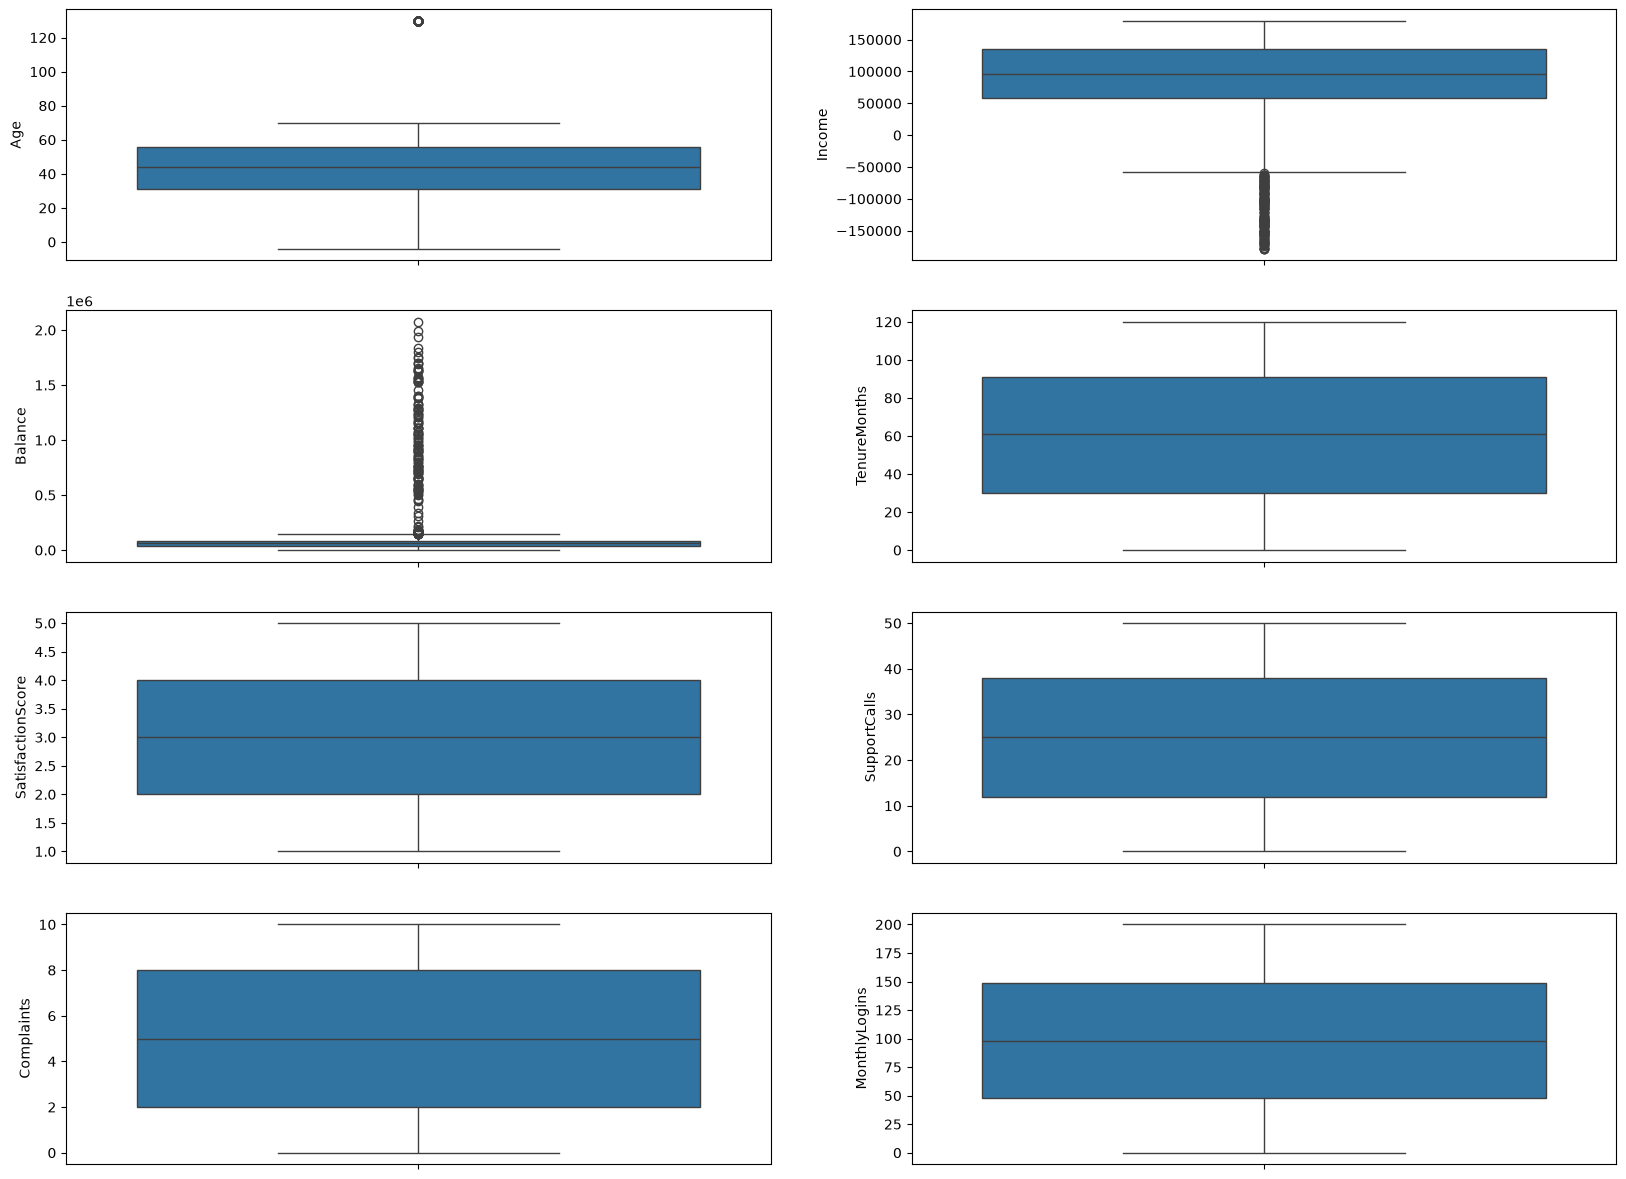

In [20]:
# Creating boxplots to see outliers

plt.figure(figsize = (20,15))
for i, col in enumerate(cols,1):
    plt.subplot(4,2,i)
    sns.boxplot(df[col])
plt.show()

In [21]:
# There are outliers in some features 

# Using IQR method for handling outliers
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_limit = Q3 + 1.5 * IQR
    lower_limit = Q1 - 1.5 * IQR
    df[col]  = df[col].clip(lower_limit , upper_limit)

# After applying IQR, if any value still remain negative then replace it with mean of that feature
for col in cols:
    for item in df[col]:
        if item  < 0:
            df[col] = df[col].replace({item : df[col].mean()})
           
df.describe().round()


,Age,Income,Balance,TenureMonths,SatisfactionScore,SupportCalls,Complaints,MonthlyLogins,Churn
count,8000.0,8000.0,8000.0,8000.0,8000.0,8000.0,8000.0,8000.0,8000.0
mean,45.0,99254.0,64021.0,60.0,3.0,25.0,5.0,99.0,0.0
std,16.0,43796.0,33853.0,35.0,1.0,15.0,3.0,58.0,0.0
min,18.0,20047.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
25%,32.0,63154.0,40296.0,30.0,2.0,12.0,2.0,48.0,0.0
50%,44.0,96558.0,65249.0,61.0,3.0,25.0,5.0,98.0,0.0
75%,56.0,135394.0,83421.0,91.0,4.0,38.0,8.0,149.0,0.0
max,94.0,179983.0,148110.0,120.0,5.0,50.0,10.0,200.0,1.0


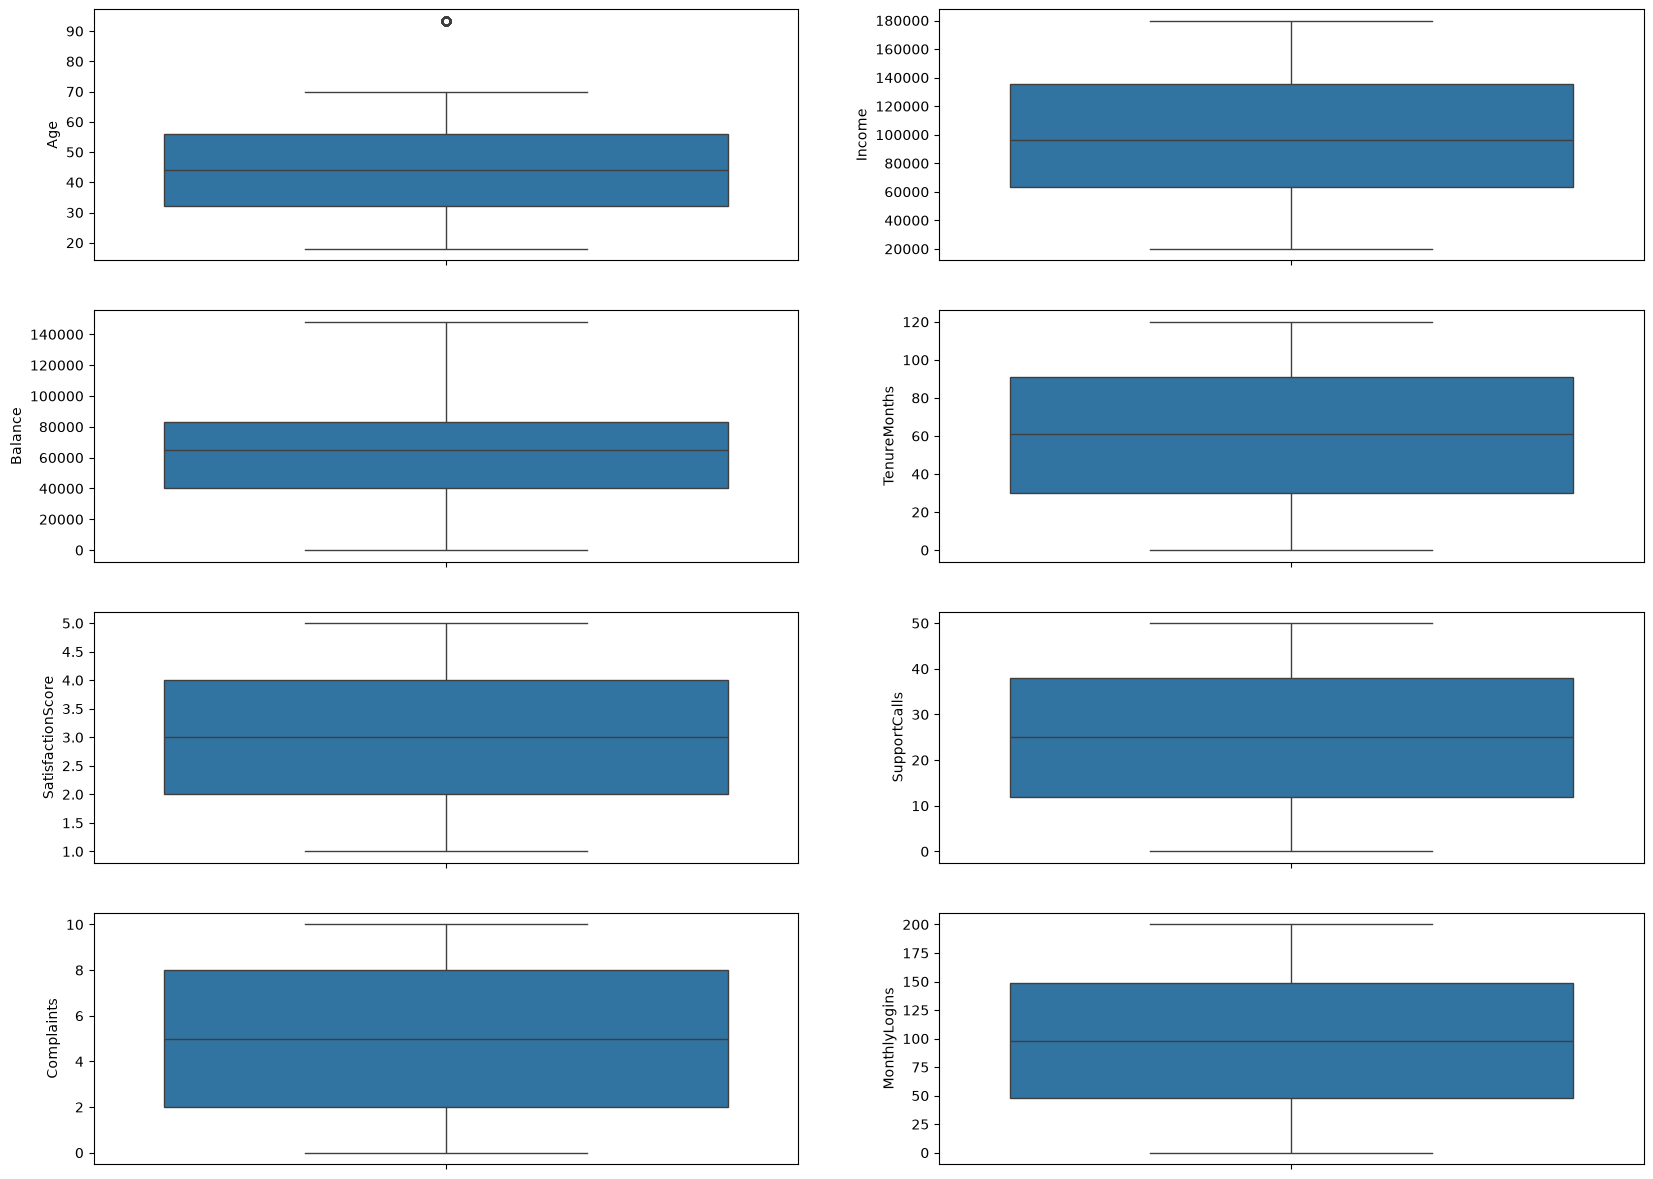

In [22]:
plt.figure(figsize = (20,15))
for i,col in enumerate(cols , 1):
    plt.subplot(4,2,i)
    sns.boxplot(df[col])
plt.show()

In [23]:
# Now, there is no outlier


## Feature Engineering

In [24]:
# Creating useful features with existing features
df['AgeGroup'] = pd.cut(df['Age'],bins = [0,18,30,45,60,100],labels = ['UnderAge','Adult','Young','MiddleAge','Senior'])
df['IncomeGroup'] = pd.qcut(df['Income'], q = 4, labels = ['Low','Medium','High','Very High'])
df['SupportCallsPerMonth'] = df['SupportCalls']/(df['TenureMonths'] + 1)
df['ComplaintRate'] = df['Complaints']/(df['SupportCalls'] + 1)
df = df.drop(columns = ['Age'])

# Rearranging target at the end
target = df.pop('Churn')
df['Churn'] = target


## Feature Encoding

In [25]:
from sklearn.preprocessing import OneHotEncoder , LabelEncoder, OrdinalEncoder

In [26]:
# Ordinal Encoder 
encoder = OrdinalEncoder(categories = [['UnderAge','Young','Adult','MiddleAge','Senior'],['Low','Medium','High','Very High']])
df[['AgeGroup','IncomeGroup']] = encoder.fit_transform(df[['AgeGroup','IncomeGroup']])

In [27]:
# One hot encoder
encoder = OneHotEncoder(handle_unknown  = 'ignore',sparse_output = False)
encoded_values = encoder.fit_transform(df[['Gender','City','SubscriptionPlan','DeviceType']])
new_cols = encoder.get_feature_names_out(['Gender','City','SubscriptionPlan','DeviceType'])

df_encoded = pd.DataFrame(encoded_values , columns = new_cols)
df = pd.concat([df.drop(columns = ['Gender','City','SubscriptionPlan','DeviceType']),df_encoded], axis = 1)


In [28]:
# Rearranging the target at the end
target = df.pop('Churn')
df['Churn'] = target
X = df.drop(columns = ['Churn'])
y = target


df.to_csv('customer_churn_cleaned_dataset.csv')

## Train/Test Split

In [29]:
X = np.array(X)
y = np.array(y)
split = StratifiedShuffleSplit(n_splits = 1,test_size = 0.2,random_state = 42)
for train_idx, test_idx in split.split(X,y):
    X_train , X_test = X[train_idx], X[test_idx]
    y_train , y_test = y[train_idx], y[test_idx]


## Feature Scaling

In [30]:
# Applying Standard Scaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model 1 for Training (LogisticRegression)

In [31]:
lr = LogisticRegression(l1_ratio = 0, max_iter = 1000,C = 5,solver = 'liblinear' , tol = 1e-4)
lr.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",5
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty 

In [32]:
print(f'Training Score: ', lr.score(X_train_scaled, y_train))
print(f'Testing Score: ', lr.score(X_test_scaled, y_test))

Training Score:  0.89046875
Testing Score:  0.889375


In [33]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve


y_scores = lr.predict_proba(X_test_scaled)[:,1] # Predicted values of X_test_scaled


In [34]:
# Calculating optimal threshold
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
optimal_idx = np.argmax(tpr-fpr)
optimal_threshold = thresholds[optimal_idx]
y_pred = (y_scores >= optimal_threshold).astype(int)
optimal_threshold

np.float64(0.14955897538694787)

In [35]:
print(f'Threshold: 0.5')
print(confusion_matrix(y_test, y_scores>=0.5)) # confusion_matrix at threshold 0.5
print('\n')
print(f'Threshold = {optimal_threshold}')
print(confusion_matrix(y_test, y_pred))

Threshold: 0.5
[[1381   12]
 [ 165   42]]


Threshold = 0.14955897538694787
[[1095  298]
 [  55  152]]


In [36]:
# Classificaion report before and after using optimal threshold

from sklearn.metrics import classification_report

print("Threshold = 0.5")
print(classification_report(y_test, y_scores>=0.5))

print("Threshold = 0.14")
print(classification_report(y_test, y_pred))

Threshold = 0.5
              precision    recall  f1-score   support

           0       0.89      0.99      0.94      1393
           1       0.78      0.20      0.32       207

    accuracy                           0.89      1600
   macro avg       0.84      0.60      0.63      1600
weighted avg       0.88      0.89      0.86      1600

Threshold = 0.14
              precision    recall  f1-score   support

           0       0.95      0.79      0.86      1393
           1       0.34      0.73      0.46       207

    accuracy                           0.78      1600
   macro avg       0.64      0.76      0.66      1600
weighted avg       0.87      0.78      0.81      1600



## Model 2 for training (DecisionTreeClassifier)

In [37]:
from sklearn.tree import DecisionTreeClassifier

In [38]:
clf = DecisionTreeClassifier(max_depth = 10, min_samples_leaf = 5, min_samples_split = 12, ccp_alpha = 0.001, max_features = 5,random_state = 42)
# Model with tuning

clf.fit(X_train_scaled, y_train) # Model fit


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",12
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"ccp_alpha ccp_alpha: non-negative float, default=0.0Complexity parameter used for Minimal Cost-Complexity Pruning. Thesubtree with the largest cost complexity that is smaller than``ccp_alpha`` will be chosen. By default, no pruning is performed. See:ref:`minimal_cost_complexity_pruning` for details. See:ref:`sphx_glr_auto_examples_tree_plot_cost_complexity_pruning.py`for an example of such pruning... versionadded:: 0.22",0.001
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None 

In [39]:
print('Training Score: ',clf.score(X_train_scaled, y_train))
print('Test Score: ', clf.score(X_test_scaled, y_test))

Training Score:  0.9728125
Test Score:  0.968125


In [40]:
y_scores1 = clf.predict_proba(X_test_scaled)[:,1] # Prediction for test smaple

# Calculating optimal threshold 
fpr1 , tpr1 , thresholds1  = roc_curve(y_test, y_scores1)
optimal_idx = np.argmax(tpr1 - fpr1)
optimal_thresholds1 = thresholds1[optimal_idx]
y_pred1 = (y_scores1 >= optimal_thresholds1).astype(int)

In [41]:
# Before and After changing thresholds
print('Threshold: 0.5')
print(confusion_matrix(y_test, y_scores>=0.5))
print('\n')
print(f'Threshold: {optimal_thresholds1}')
print(confusion_matrix(y_test,y_pred1))

Threshold: 0.5
[[1381   12]
 [ 165   42]]


Threshold: 0.16289592760180996
[[1325   68]
 [  27  180]]


In [42]:
# Before and After changing thresholds
print('Threshold: 0.5')
print(classification_report(y_test, y_scores>=0.5))
print('\n')
print(f'Threshold: {optimal_thresholds1}')
print(classification_report(y_test,y_pred1))

Threshold: 0.5
              precision    recall  f1-score   support

           0       0.89      0.99      0.94      1393
           1       0.78      0.20      0.32       207

    accuracy                           0.89      1600
   macro avg       0.84      0.60      0.63      1600
weighted avg       0.88      0.89      0.86      1600



Threshold: 0.16289592760180996
              precision    recall  f1-score   support

           0       0.98      0.95      0.97      1393
           1       0.73      0.87      0.79       207

    accuracy                           0.94      1600
   macro avg       0.85      0.91      0.88      1600
weighted avg       0.95      0.94      0.94      1600



## ROC - AUC

In [43]:
from sklearn.metrics import roc_auc_score
import plotly.graph_objects as go

In [44]:
# Calculating ROC - AUC for both models
auc0 = roc_auc_score(y_test, y_pred)
auc1 = roc_auc_score(y_test, y_pred1)


In [45]:
trace0 = go.Scatter(
    x = fpr,
    y = tpr, 
    mode = 'lines',
    name = f'Logistic Regression (Area {auc0})',
    line = dict(color = 'green')
)

trace1 = go.Scatter(
    x = fpr1, 
    y = tpr1,
    mode = 'lines',
    name = f'DecisionTreeClassifier (Area {auc1})',
    line = dict(color = 'blue')
)

trace2 = go.Scatter(
    x = [0,1],
    y = [0,1],
    mode = 'lines',
    line = dict(dash = 'dash'),
    name = 'Line'

)

data = [trace0 , trace1 , trace2]

layout = go.Layout(
    xaxis = dict(title = 'False Positive Rate (FPR)'),
    yaxis  = dict(title = 'True Positive Rate (TPR)'),
    title = 'Threshold Curves',
    autosize = False,
    width =800,
    height = 800,
    showlegend = True
)

fig = go.Figure(data = data, layout = layout)
fig.show()

## Conclusion

### This project focused on predicting customer churn using machine learning techniques. The dataset was first cleaned by handling missing values, removing duplicate records, correcting inconsistent formatting, and treating outliers to improve data quality. Feature engineering and preprocessing techniques such as encoding, feature scaling, and train-test splitting were then applied to prepare the data for model training.

 ### Two machine learning models, Logistic Regression and Decision Tree Classifier, were trained and evaluated using metrics such as Accuracy, Precision, Recall, F1-Score, Confusion Matrix, ROC Curve, and ROC-AUC Score. In addition, threshold optimization was performed for Logistic Regression to study the trade-off between precision and recall. The optimized threshold significantly improved the model's ability to identify customers who were likely to churn, demonstrating that accuracy alone is not always the best metric for evaluating classification models.

### Overall, this project provided practical experience in the complete machine learning workflow, including data preprocessing, feature engineering, model building, evaluation, and performance optimization. It also highlighted the importance of selecting appropriate evaluation metrics and decision thresholds based on business requirements to build effective predictive models.